In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Load your cleaned NAV data
# Assuming your df has columns: 'date', 'nav', 'scheme_name' (or 'amfi_code')
df_nav = pd.read_csv('../data/processed/cleaned_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])

# 2. Create the base line chart for all 40 schemes
fig = px.line(
    df_nav, 
    x='date', 
    y='nav', 
    color='amfi_code', # Changed from scheme_name
    title='Daily NAV Trend Analysis (2022-2026) Across All Schemes',
    labels={'nav': 'Net Asset Value (NAV)', 'date': 'Date', 'amfi_code': 'AMFI Code'} 
)

# 3. Highlight the 2023 Bull Run (e.g., roughly April 2023 to Dec 2023 - adjust dates as needed based on your dataset)
fig.add_vrect(
    x0="2023-04-01", x1="2023-12-31", 
    fillcolor="green", opacity=0.1, 
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# 4. Highlight the 2024 Market Corrections (e.g., rough estimate - adjust as needed)
fig.add_vrect(
    x0="2024-05-01", x1="2024-07-31", 
    fillcolor="red", opacity=0.1, 
    layer="below", line_width=0,
    annotation_text="2024 Market Correction", annotation_position="top left"
)

# 5. Clean up the layout
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    legend=dict(title=None, orientation="h", y=-0.2) # Moves legend below for cleaner view
)

# Show the interactive plot
fig.show()

# Export to PNG for the final report deliverable
# fig.write_image("reports/nav_trend_analysis.png", width=1200, height=800)

Finding 1: The NAV trend across all 40 schemes shows steady upward momentum during the 2023 Bull Run, with one specific outlier fund (AMFI 120503) experiencing extreme, detached growth compared to the rest of the market.

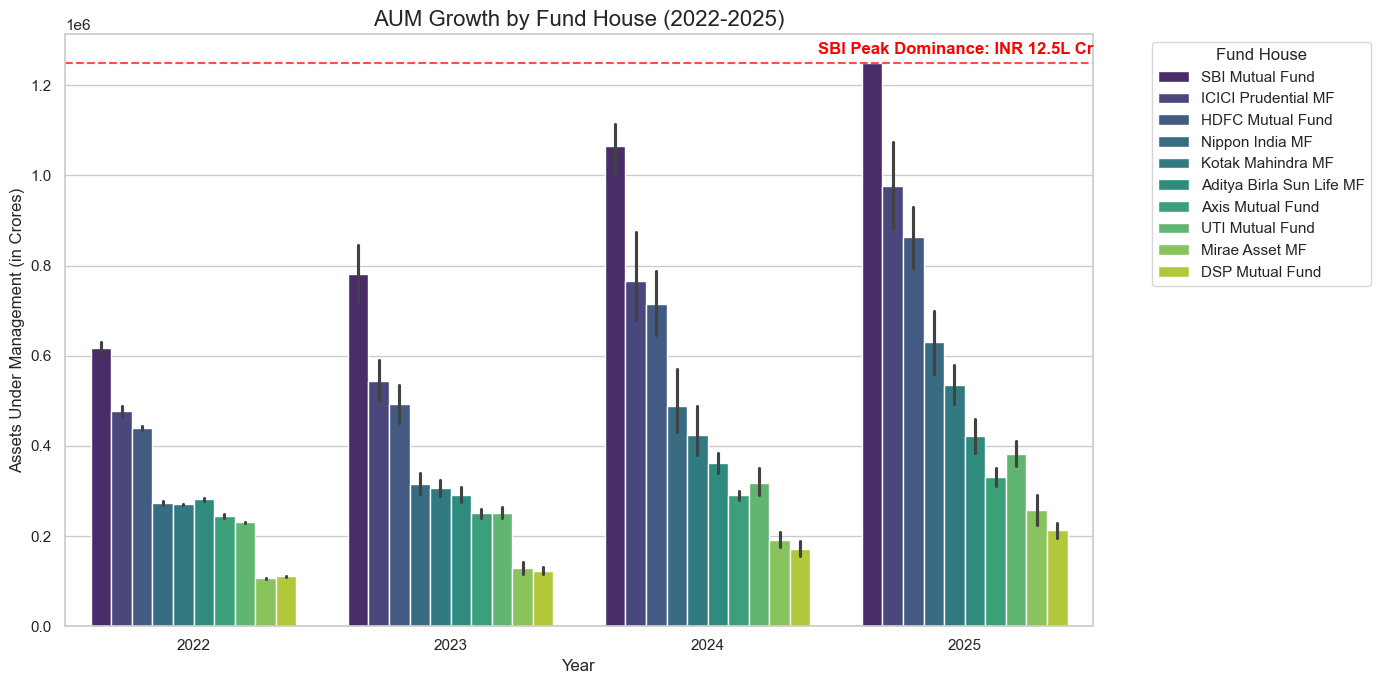

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and prep data cleanly from scratch
df_aum = pd.read_csv('../data/raw/03_aum_by_fund_house.csv')
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

# 2. Filter for years 2022-2025
df_aum_filtered = df_aum[df_aum['year'].isin([2022, 2023, 2024, 2025])]

# 3. Set up the figure
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 4. Create the grouped bar chart
ax = sns.barplot(
    data=df_aum_filtered, 
    x='year', 
    y='aum_crore', 
    hue='fund_house',
    palette='viridis' 
)

# 5. Highlight SBI's dominance (Swapped ₹ for INR)
plt.axhline(y=1250000, color='red', linestyle='--', alpha=0.7)
plt.text(
    x=3.5, 
    y=1270000, 
    s="SBI Peak Dominance: INR 12.5L Cr", 
    color='red', 
    fontweight='bold',
    horizontalalignment='right'
)

# 6. Clean up labels and title
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Assets Under Management (in Crores)', fontsize=12)
plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import plotly.express as px

# 1. Load the SIP inflows dataset
df_sip = pd.read_csv('../data/raw/04_monthly_sip_inflows.csv')

# 2. Convert the 'month' column to datetime and filter for Jan 2022 - Dec 2025
df_sip['month'] = pd.to_datetime(df_sip['month'])
mask = (df_sip['month'] >= '2022-01-01') & (df_sip['month'] <= '2025-12-31')
df_sip_filtered = df_sip.loc[mask]

# 3. Create the time-series line chart
fig = px.line(
    df_sip_filtered, 
    x='month', 
    y='sip_inflow_crore', 
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow Amount (₹ Crores)', 'month': 'Month'},
    markers=True
)

# 4. Annotate the ₹31,002 Cr all-time high in Dec 2025
fig.add_annotation(
    x='2025-12-01',  # Note: If your CSV uses end-of-month dates, change this to '2025-12-31'
    y=31002,         
    text="All-time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636EFA",
    ax=-60,
    ay=-40,
    font=dict(size=12, color="white"),
    bgcolor="#636EFA",
    bordercolor="#636EFA",
    borderpad=4
)

# 5. Clean up the layout
fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

# Show the plot
fig.show()

/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.



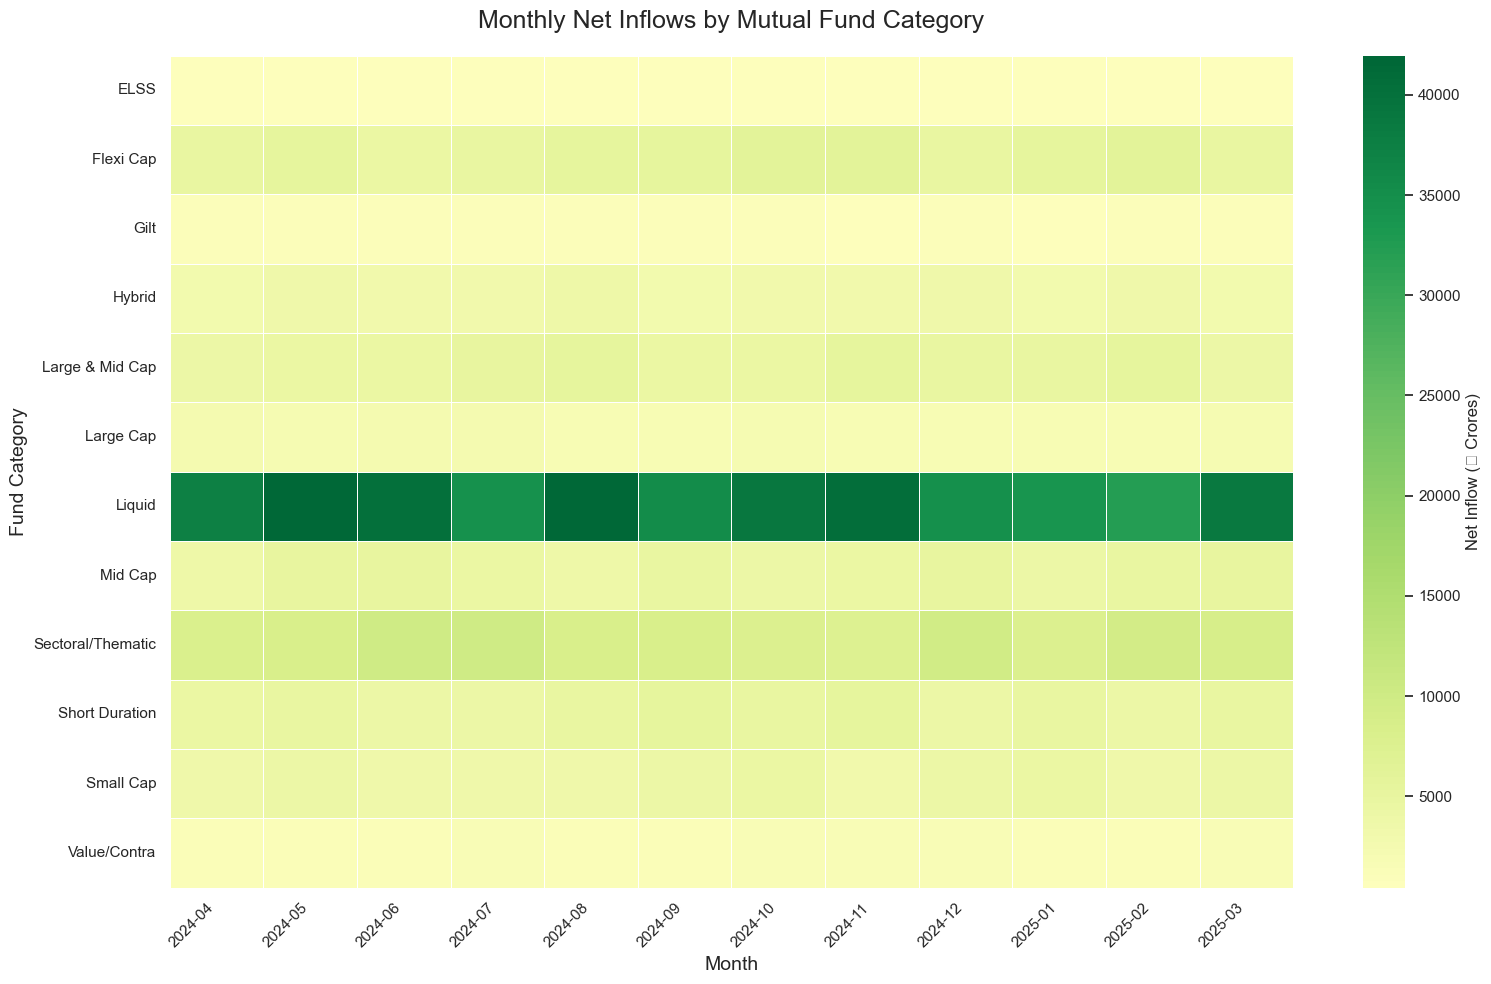

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the category inflows dataset
df_cat = pd.read_csv('../data/raw/05_category_inflows.csv')

# 2. Reshape the data for a heatmap using your exact column names
heatmap_data = df_cat.pivot(
    index='category',          # Y-axis
    columns='month',           # X-axis
    values='net_inflow_crore'  # Color intensity
)

# 3. Set up the matplotlib figure
plt.figure(figsize=(16, 10))
sns.set_theme(style="white")

# 4. Create the heatmap
# Using RdYlGn (Red-Yellow-Green) so outflows are red and inflows are green
ax = sns.heatmap(
    heatmap_data, 
    cmap="RdYlGn",       
    center=0,            
    annot=False,         
    linewidths=.5, 
    cbar_kws={'label': 'Net Inflow (₹ Crores)'}
)

# 5. Clean up labels and title
plt.title('Monthly Net Inflows by Mutual Fund Category', fontsize=18, pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Fund Category', fontsize=14)

# Rotate x-axis labels so the months are readable
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/var/folders/h5/dccvd8590q5_bk7rj00bmgtr0000gn/T/ipykernel_95179/974958456.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/h5/dccvd8590q5_bk7rj00bmgtr0000gn/T/ipykernel_95179/974958456.py:53: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.



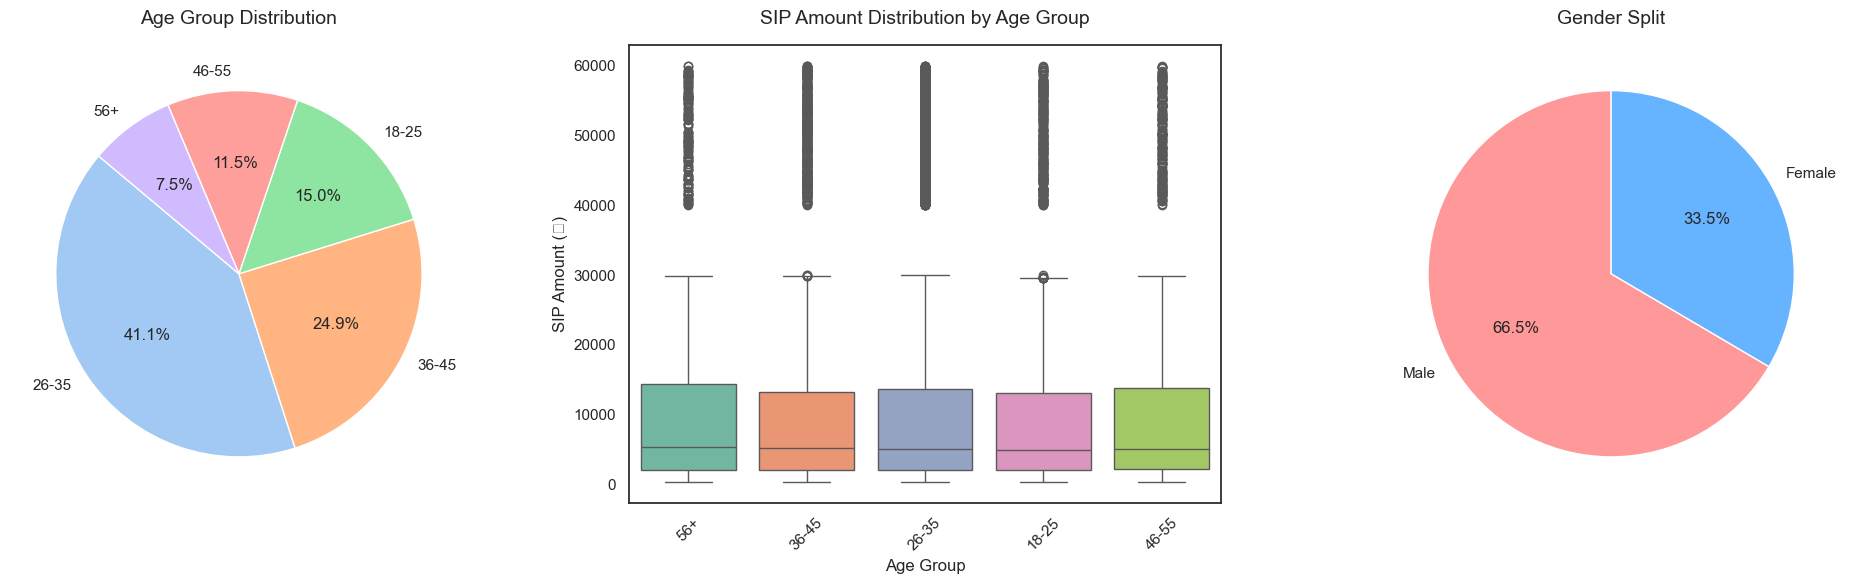

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the investor transactions dataset
df_investor = pd.read_csv('../data/raw/08_investor_transactions.csv')

# 2. Filter specifically for SIP transactions for the box plot
# Standardizing the text to uppercase just in case of messy data
df_investor['transaction_type'] = df_investor['transaction_type'].astype(str).str.upper().str.strip()
df_sip = df_investor[df_investor['transaction_type'] == 'SIP']

# 3. Set up a 1x3 grid for the three charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# --- CHART 1: Age Group Distribution Pie Chart ---
age_counts = df_investor['age_group'].value_counts()
axes[0].pie(
    age_counts, 
    labels=age_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel")
)
axes[0].set_title('Age Group Distribution', fontsize=14, pad=15)

# --- CHART 2: SIP Amount Box Plot by Age Group ---
sns.boxplot(
    data=df_sip, 
    x='age_group', 
    y='amount_inr',  # Updated to exact column name
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=14, pad=15)
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)

# --- CHART 3: Gender Split Pie Chart ---
gender_counts = df_investor['gender'].value_counts()
axes[2].pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999','#66b3ff','#99ff99']
)
axes[2].set_title('Gender Split', fontsize=14, pad=15)

# 4. Clean up the layout and display
plt.tight_layout()
plt.show()

/var/folders/h5/dccvd8590q5_bk7rj00bmgtr0000gn/T/ipykernel_95179/2380010411.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/h5/dccvd8590q5_bk7rj00bmgtr0000gn/T/ipykernel_95179/2380010411.py:39: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.



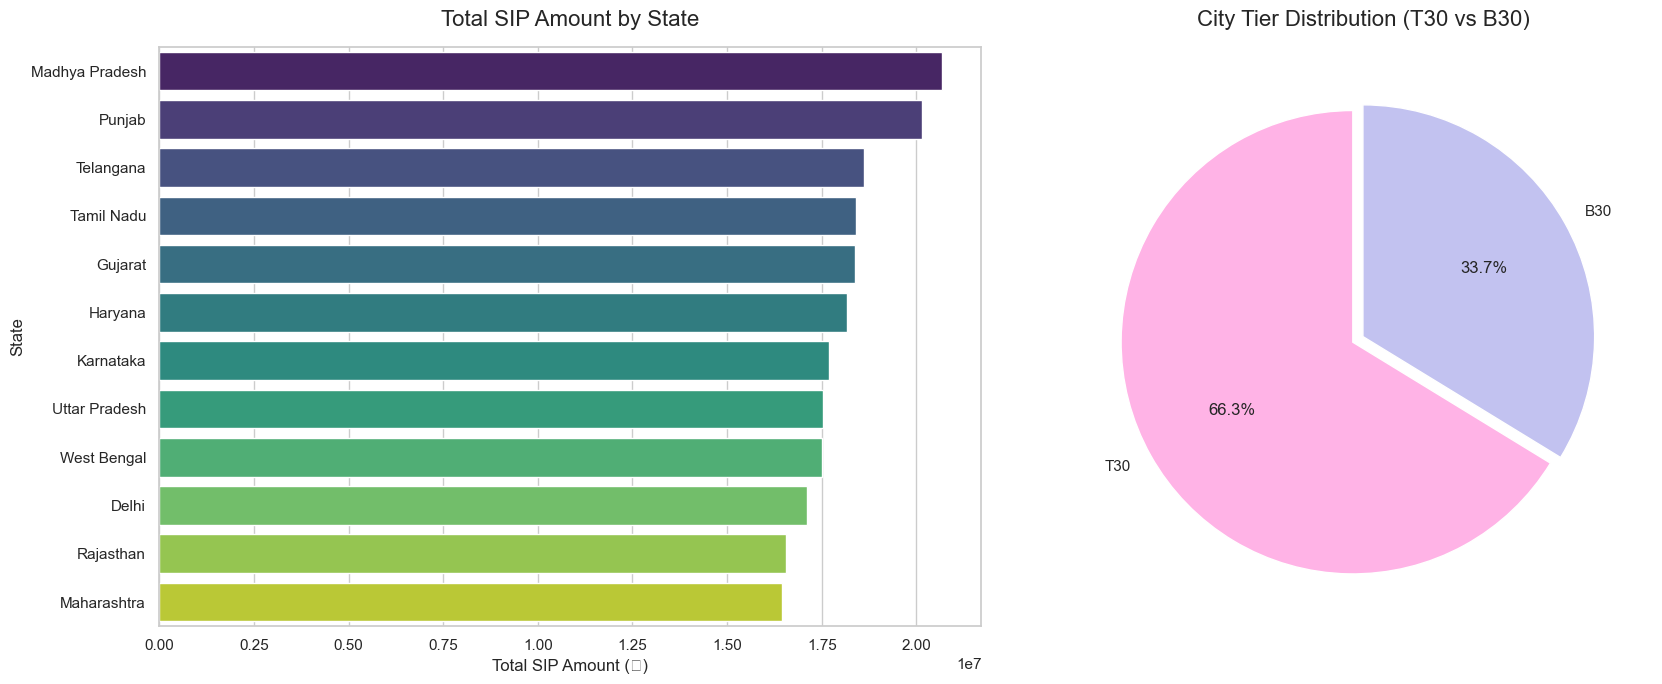

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the SIP data by state to get total amounts
# We use df_sip which we already filtered in the previous step
state_sip = df_sip.groupby('state')['amount_inr'].sum().reset_index()
state_sip = state_sip.sort_values(by='amount_inr', ascending=False)

# 2. Set up a 1x2 grid for the geographic charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# --- CHART 1: Horizontal Bar Chart of SIP Amount by State ---
sns.barplot(
    data=state_sip, 
    x='amount_inr', 
    y='state', 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title('Total SIP Amount by State', fontsize=16, pad=15)
axes[0].set_xlabel('Total SIP Amount (₹)', fontsize=12)
axes[0].set_ylabel('State', fontsize=12)

# --- CHART 2: T30 vs B30 City Tier Pie Chart ---
tier_counts = df_investor['city_tier'].value_counts()
axes[1].pie(
    tier_counts, 
    labels=tier_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ffb3e6', '#c2c2f0'],
    explode=(0.05, 0) # Slightly separates the slices for a cleaner look
)
axes[1].set_title('City Tier Distribution (T30 vs B30)', fontsize=16, pad=15)

# 3. Clean up the layout and display
plt.tight_layout()
plt.show()

Columns found: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39


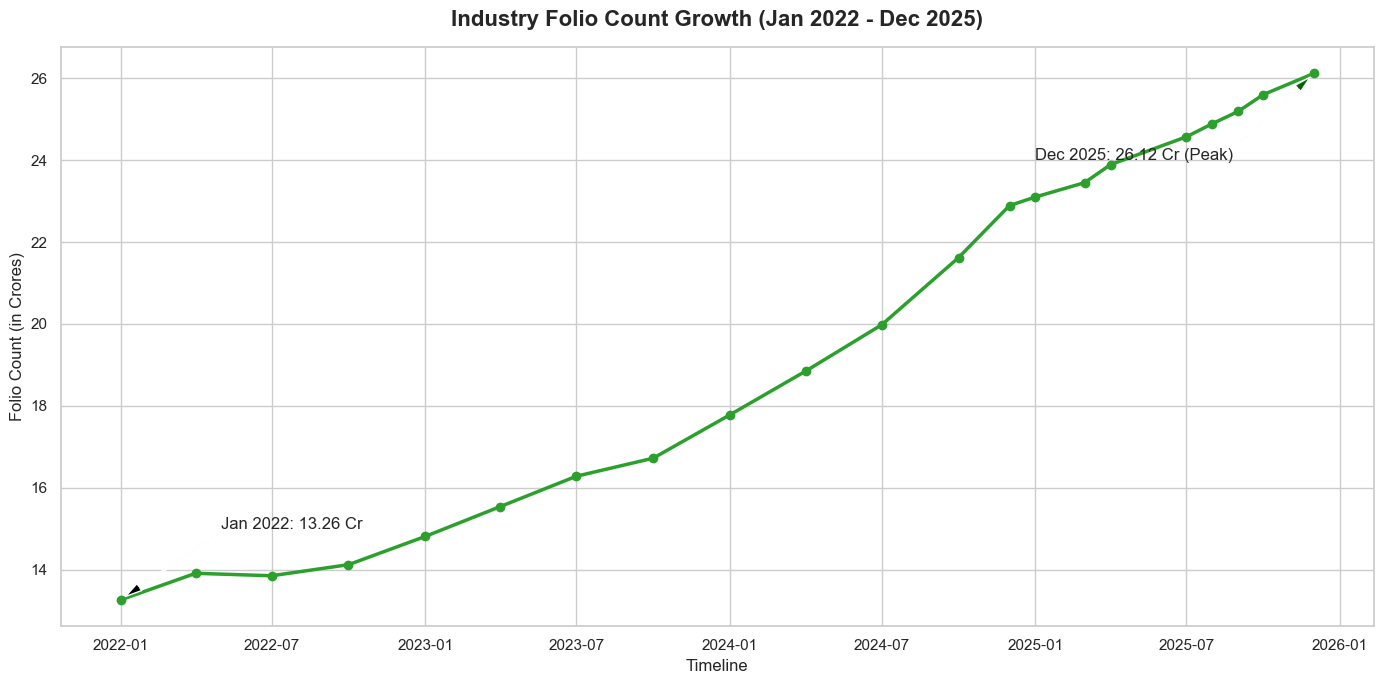

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the folio count dataset
df_folio = pd.read_csv('../data/raw/06_industry_folio_count.csv')

# Let's dynamically check columns to be safe
print("Columns found:", df_folio.columns.tolist())
display(df_folio.head(2))

# We will try mapping based on standard names. 
# (If your columns are capitalized like 'Month' or 'Folio_Count_Cr', adjust below)
date_col = 'month' if 'month' in df_folio.columns else df_folio.columns[0]
folio_col = 'folio_count_crore' if 'folio_count_crore' in df_folio.columns else df_folio.columns[1]

# 2. Convert and sort data
df_folio[date_col] = pd.to_datetime(df_folio[date_col])
df_folio = df_folio.sort_values(by=date_col)

# 3. Set up the figure
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 4. Plot the growth line
plt.plot(df_folio[date_col], df_folio[folio_col], marker='o', color='#2ca02c', linewidth=2.5, label='Total Folios')

# 5. Mark key milestones requested by the ticket
# Milestone 1: Jan 2022 (13.26 Cr)
plt.annotate('Jan 2022: 13.26 Cr', 
             xy=(pd.to_datetime('2022-01-01'), 13.26), 
             xytext=(pd.to_datetime('2022-05-01'), 15.0),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Milestone 2: Dec 2025 (26.12 Cr)
plt.annotate('Dec 2025: 26.12 Cr (Peak)', 
             xy=(pd.to_datetime('2025-12-01'), 26.12), 
             xytext=(pd.to_datetime('2025-01-01'), 24.0),
             arrowprops=dict(facecolor='darkgreen', shrink=0.05, width=1, headwidth=6))

# 6. Titles and Clean layout
plt.title('Industry Folio Count Growth (Jan 2022 - Dec 2025)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Folio Count (in Crores)', fontsize=12)

plt.tight_layout()
plt.show()

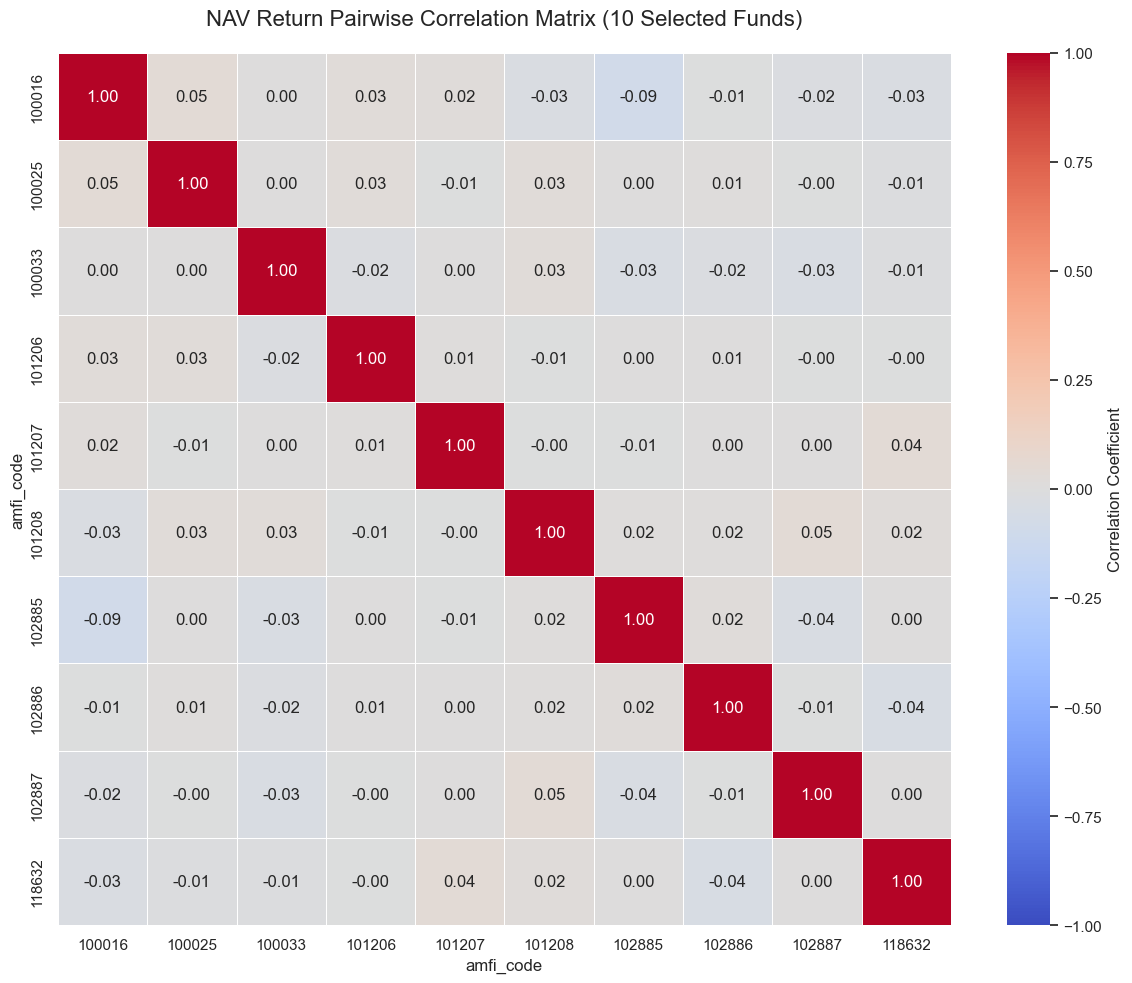

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your cleaned NAV data
df_nav = pd.read_csv('../data/processed/cleaned_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])

# 2. Pick 10 unique fund schemes (amfi_codes) from your dataset
selected_funds = df_nav['amfi_code'].unique()[:10]
df_filtered = df_nav[df_nav['amfi_code'].isin(selected_funds)]

# 3. Pivot the data so columns are the funds and rows are the dates
df_pivot = df_filtered.pivot(index='date', columns='amfi_code', values='nav')

# 4. Calculate daily percentage returns
df_returns = df_pivot.pct_change().dropna()

# 5. Compute the pairwise correlation matrix
corr_matrix = df_returns.corr()

# 6. Plot the correlation matrix heatmap using Seaborn
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Creating a clean diverging colormap (Coolwarm is great for correlations)
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the correlation coefficients in each box
    fmt=".2f",           # Formats to 2 decimal places
    cmap="coolwarm",     
    vmin=-1, vmax=1,     # Anchors the scale from -1 to 1
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

# 7. Add titles and layout cleanups
plt.title('NAV Return Pairwise Correlation Matrix (10 Selected Funds)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

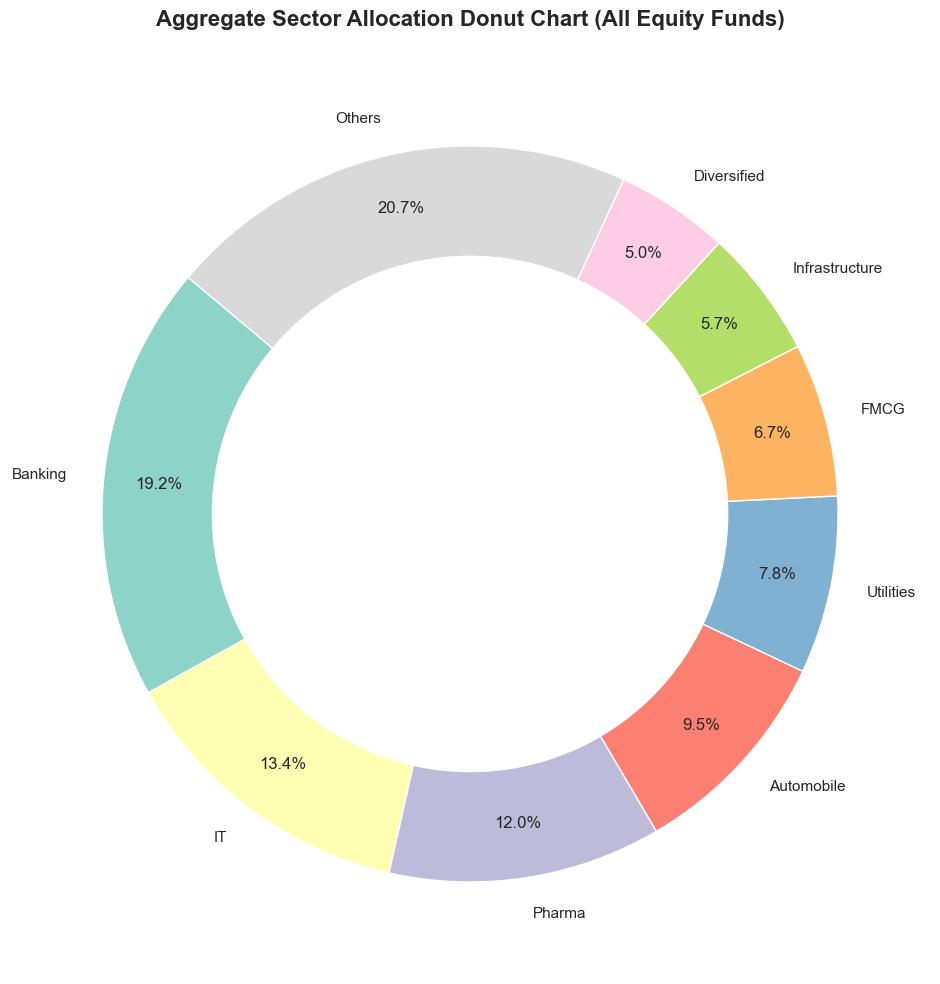

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the portfolio holdings dataset
df_holdings = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

# 2. Aggregate sector weights across all funds 
# Grouping by your exact column names: 'sector' and 'weight_pct'
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector_weights = sector_weights.sort_values(by='weight_pct', ascending=False)

# Take the top 8 sectors and group the remaining ones into 'Others'
top_sectors = sector_weights.head(8)
others_weight = sector_weights.iloc[8:]['weight_pct'].sum()
others_df = pd.DataFrame([{'sector': 'Others', 'weight_pct': others_weight}])
final_sectors = pd.concat([top_sectors, others_df])

# 3. Create the Donut Chart
plt.figure(figsize=(10, 10))

plt.pie(
    final_sectors['weight_pct'], 
    labels=final_sectors['sector'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Set3"),
    pctdistance=0.85
)

# Draw the center circle to create the donut look
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Clean layout
plt.title('Aggregate Sector Allocation Donut Chart (All Equity Funds)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()